# Extended Two-Way Fixed Effects (ETWFE) for Staggered DiD

This notebook is about the second estimator available on CausalPy's `StaggeredDifferenceInDifferences` class: Wooldridge's **extended two-way fixed effects** estimator {cite:p}`wooldridge2021twoway`, reached by passing `estimator="etwfe"`.

The companion notebook [Staggered Difference-in-Differences](staggered-difference-in-differences-pymc.ipynb) covers the default `estimator="imputation"` path, which implements the Borusyak–Jaravel–Spiess imputation estimator {cite:p}`borusyak2024revisiting`. Both estimators target the same estimand and live behind the same entry point, so you can flip between them by changing one keyword.

## What this notebook shows

1. A panel with {term}`Staggered Difference-in-Differences` adoption where the treatment effect **grows with event time** and is **larger for the later-adopting cohort**. This is precisely the configuration in which a single-coefficient two-way fixed effects regression is known to fail.
2. That naive regression, fit by hand, missing the true average effect on the treated by a wide margin — and *why*.
3. The imputation estimator, for reference.
4. `estimator="etwfe"`, which puts one effect parameter on every (cohort, event-time) cell and aggregates them **inside** the model.
5. The two conditioning schemes, `"mundlak"` and `"dummy"`.
6. Lead terms (`n_leads`) as a pre-trend diagnostic.
7. Covariates, and an honest account of what they do and do not buy you.
8. The scikit-learn path with cluster-robust standard errors.

## The estimator in one paragraph

The classical two-way fixed effects (TWFE) regression writes

$$Y_{it} = \alpha_i + \lambda_t + \delta D_{it} + \varepsilon_{it},$$

with a single scalar $\delta$. ETWFE replaces that scalar with a **saturated set of effects**, one for each combination of adoption cohort $g$ and event time $k = t - g$:

$$Y_{it} = \alpha_i + \lambda_t + E_{it}\,\tau_{g(i),\,k(i,t)} + \varepsilon_{it}.$$

Nothing is averaged before estimation. The headline number is then formed *afterwards* as an explicit average over the treated cells,

$$\text{ATT} = \sum_{g,k} w_{gk}\,\tau_{gk}, \qquad w_{gk} = \frac{N_{gk}}{\sum_{g',k'} N_{g'k'}},$$

where $N_{gk}$ counts treated observations in cell $(g,k)$. In CausalPy's PyMC implementation that weighted sum is a `pm.Deterministic` **inside** the model, so it arrives with its own posterior rather than being reassembled from posterior-predictive draws after the fact.

In [1]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import patsy
from sklearn.linear_model import LinearRegression

import causalpy as cp
from causalpy.data.simulate_data import generate_staggered_did_data

warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
%config InlineBackend.figure_format = 'retina'

## 1. A panel built to break the naive estimator

`generate_staggered_did_data` accepts a **callable** treatment-effect profile, evaluated at each event time $k$, and a `cohort_effect_scale` dictionary that multiplies a whole cohort's profile. Together these give us the two features that matter here:

- **Dynamic effects.** `treatment_effects=lambda k: 1 + 0.4 * k` — the effect starts at 1.0 in the first treated period and grows by 0.4 each period thereafter. It never plateaus within the panel.
- **Cohort heterogeneity.** `cohort_effect_scale={5: 1.0, 9: 1.6}` — the cohort adopting at $t=9$ responds 60% more strongly at every event time than the cohort adopting at $t=5$.

40 units are observed over 16 periods. Twelve adopt at $t = 5$, twelve at $t = 9$, and the remaining sixteen are never treated.

In [3]:
sim_kwargs = dict(
    n_units=40,
    n_time_periods=16,
    treatment_cohorts={5: 12, 9: 12},
    treatment_effects=lambda k: 1 + 0.4 * k,
    cohort_effect_scale={5: 1.0, 9: 1.6},
    unit_fe_scale=2.0,
    time_fe_scale=1.0,
    sigma=0.3,
    seed=7,
)

df = generate_staggered_did_data(**sim_kwargs)
df.head()

,unit,time,treated,treatment_time,y,y0,tau
0,0,0,0,inf,0.218701,0.112924,0.0
1,0,1,0,inf,0.030011,0.066242,0.0
2,0,2,0,inf,-1.281781,-1.222596,0.0
3,0,3,0,inf,-0.255620,0.078601,0.0
4,0,4,0,inf,1.357827,1.361284,0.0


The generator carries ground truth in-frame. `y0` is the untreated potential outcome and `tau` is the true effect at that observation, so the estimand — the average effect over the treated cells — is available exactly:

$$\text{ATT}_{\text{true}} = \frac{1}{N_{\text{treated}}}\sum_{(i,t)\,:\,D_{it}=1} \tau_{it}.$$

This is the number every estimator below is trying to recover.

In [4]:
TRUE_ATT = df.loc[df["treated"] == 1, "tau"].mean()

print(
    f"Panel dimensions: {df['unit'].nunique()} units x {df['time'].nunique()} periods"
)
print(f"Total observations:      {len(df)}")
print(f"Treated observations:    {int(df['treated'].sum())}")
print()
print("Units per adoption cohort:")
print(df.groupby("treatment_time")["unit"].nunique().to_string())
print()
print(f"True ATT over treated cells: {TRUE_ATT:.4f}")

Panel dimensions: 40 units x 16 periods
Total observations:      640
Treated observations:    216

Units per adoption cohort:
treatment_time
5.0    12
9.0    12
inf    16

True ATT over treated cells: 3.2022


### The adoption pattern

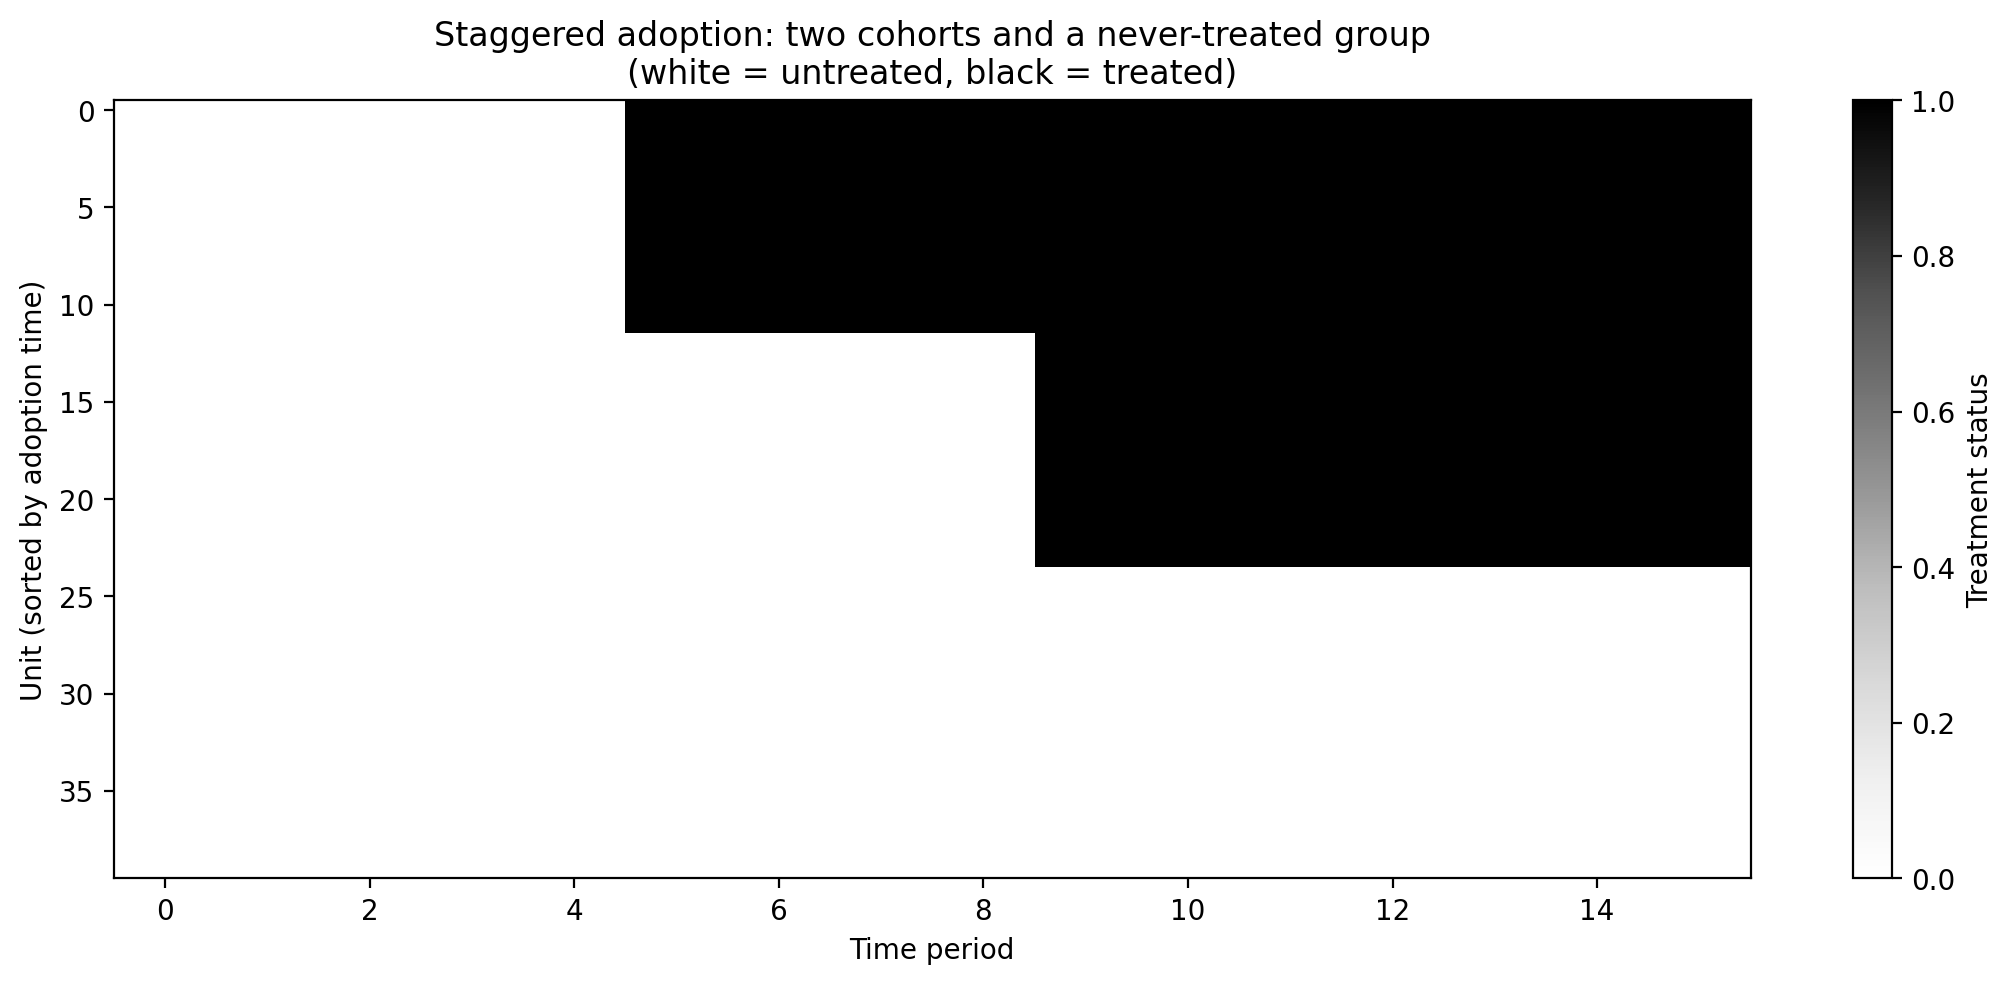

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))

treatment_matrix = df.pivot(index="unit", columns="time", values="treated")
unit_order = df.groupby("unit")["treatment_time"].first().sort_values().index
treatment_matrix = treatment_matrix.loc[unit_order]

im = ax.imshow(
    treatment_matrix.values,
    aspect="auto",
    cmap="Greys",
    interpolation="nearest",
    vmin=0,
    vmax=1,
)
ax.set_xlabel("Time period")
ax.set_ylabel("Unit (sorted by adoption time)")
ax.set_title(
    "Staggered adoption: two cohorts and a never-treated group\n"
    "(white = untreated, black = treated)"
)
plt.colorbar(im, ax=ax, label="Treatment status")
plt.tight_layout()
plt.show()

### Cohort mean trajectories

The staircase in the heatmap is the design. Its consequence is visible in the outcome paths: each cohort separates from the never-treated group at its own adoption date, and the gap then *widens*, because the effect grows with event time. The later cohort's gap widens faster, because its effects are scaled up.

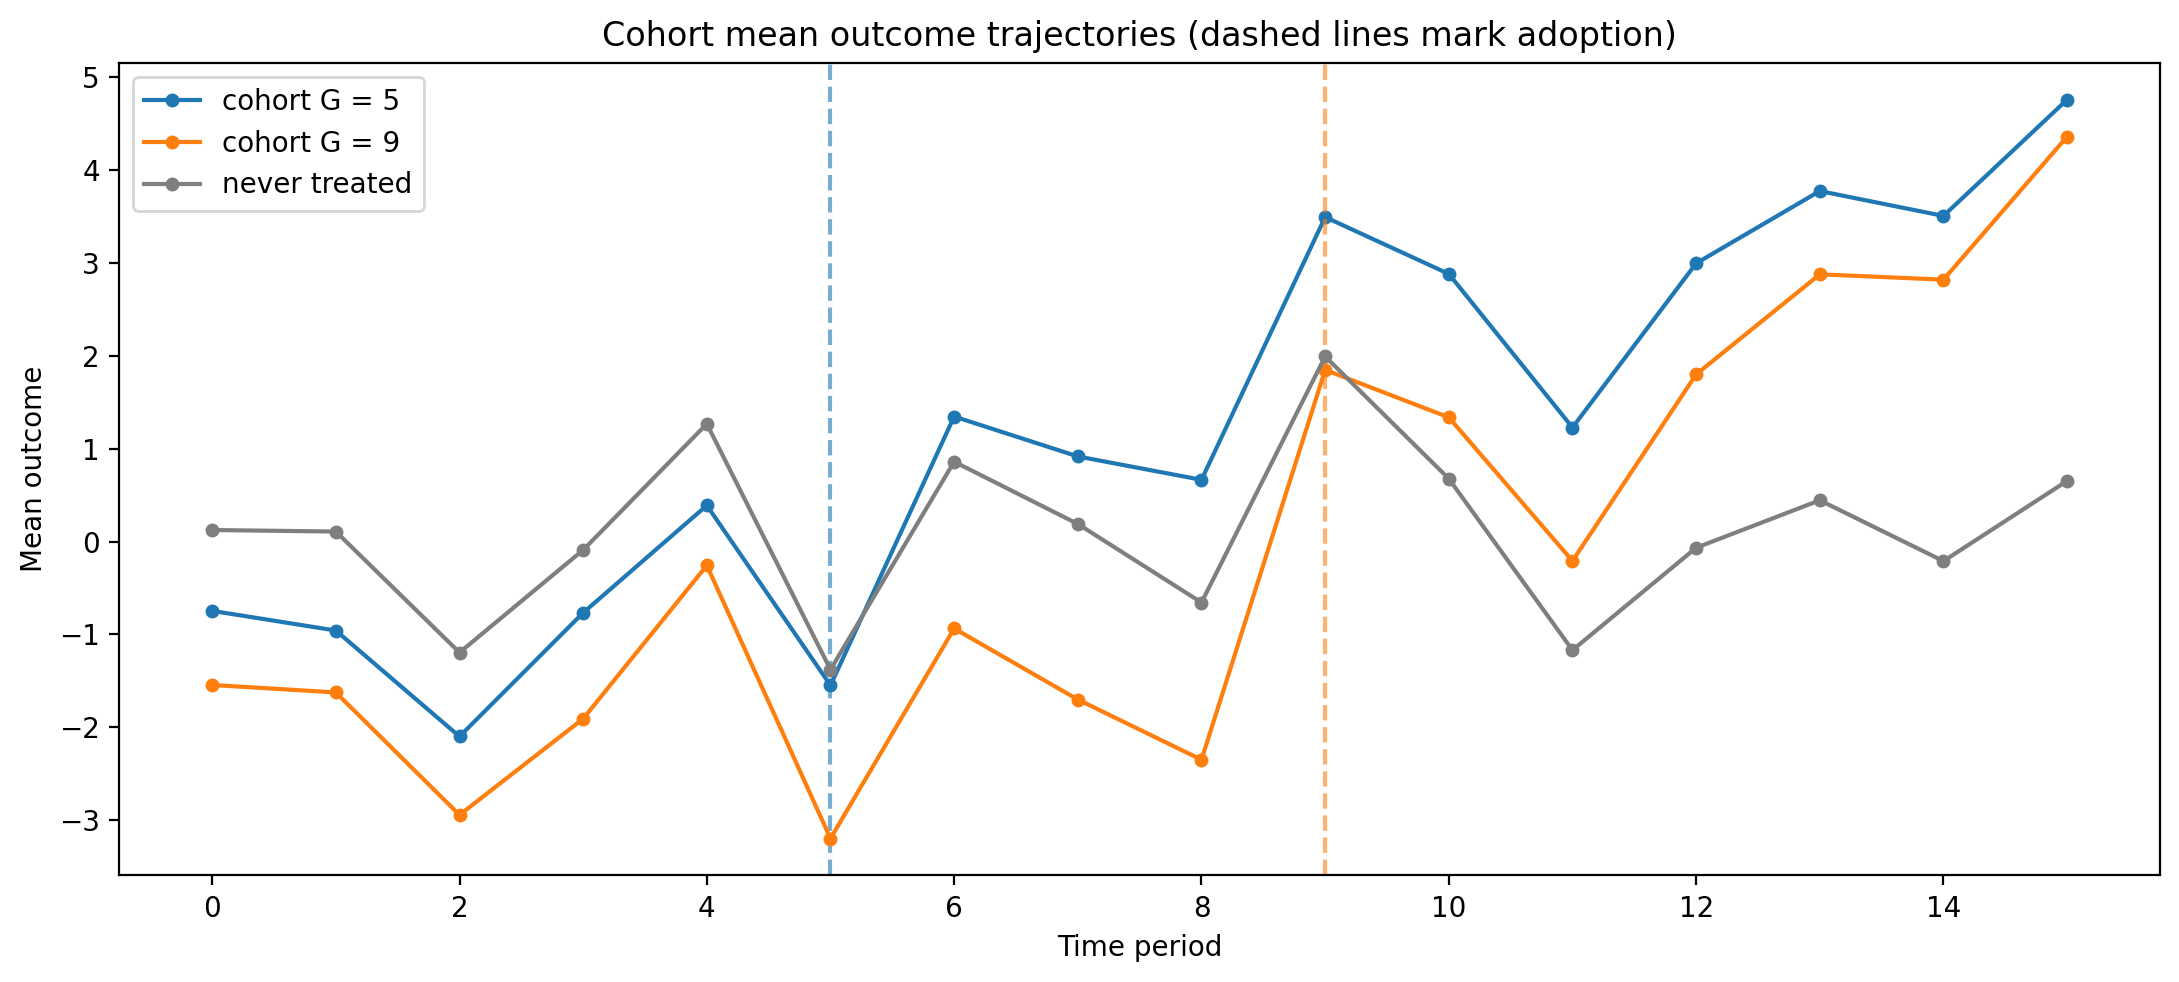

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))

cohort_means = df.groupby(["treatment_time", "time"])["y"].mean().unstack(0)
colors = {5.0: "C0", 9.0: "C1", np.inf: "C7"}

for cohort in cohort_means.columns:
    label = "never treated" if np.isinf(cohort) else f"cohort G = {int(cohort)}"
    ax.plot(
        cohort_means.index,
        cohort_means[cohort],
        marker="o",
        markersize=4,
        color=colors[cohort],
        label=label,
    )
    if not np.isinf(cohort):
        ax.axvline(cohort, color=colors[cohort], linestyle="--", alpha=0.6)

ax.set_xlabel("Time period")
ax.set_ylabel("Mean outcome")
ax.set_title("Cohort mean outcome trajectories (dashed lines mark adoption)")
ax.legend()
plt.tight_layout()
plt.show()

## 2. The naive single-$\delta$ TWFE regression

Before reaching for any of CausalPy's estimators, fit the regression that a practitioner would write first. It is a two-way fixed effects model with one treatment dummy, built explicitly with patsy and solved with `np.linalg.lstsq` so that there is no library machinery between us and the arithmetic:

$$Y_{it} = \alpha_i + \lambda_t + \delta D_{it} + \varepsilon_{it}.$$

In [7]:
y_vec, X_twfe = patsy.dmatrices(
    "y ~ 1 + C(unit) + C(time) + treated", df, return_type="dataframe"
)
coefs, *_ = np.linalg.lstsq(X_twfe.values, y_vec.values.ravel(), rcond=None)

j_treated = list(X_twfe.columns).index("treated")
delta_twfe = float(coefs[j_treated])

# Classical OLS standard error, so we can judge whether the miss is noise.
residuals = y_vec.values.ravel() - X_twfe.values @ coefs
dof = len(residuals) - np.linalg.matrix_rank(X_twfe.values)
vcov = (residuals @ residuals / dof) * np.linalg.pinv(X_twfe.values.T @ X_twfe.values)
delta_se = float(np.sqrt(vcov[j_treated, j_treated]))

print(f"Naive TWFE delta:  {delta_twfe:.4f}  (SE {delta_se:.4f})")
print(f"True ATT:          {TRUE_ATT:.4f}")
print(f"Absolute error:    {abs(delta_twfe - TRUE_ATT):.4f}")
print(f"Error in SE units: {abs(delta_twfe - TRUE_ATT) / delta_se:.1f}")

Naive TWFE delta:  2.8219  (SE 0.0932)
True ATT:          3.2022
Absolute error:    0.3803
Error in SE units: 4.1


The naive regression returns $\hat\delta = 2.82$ against a true ATT of $3.20$ — it understates the effect by $0.38$, about 12%. That is not sampling noise: the coefficient's own standard error is $0.093$, so the miss is roughly **four standard errors**. Worse, it will not shrink as the panel grows, because it is bias rather than variance. A tighter interval around the wrong number is not an improvement.

### Why it misses

{cite:t}`goodmanbacon2021difference` shows that with staggered timing the single $\delta$ is a **weighted average of every possible $2\times2$ DiD comparison** you could form from the panel. Some of those comparisons are the ones you want: a cohort that has just adopted, contrasted against units that have not yet adopted. But others use **already-treated units as the control group** — the $t=5$ cohort serves as a "control" for the $t=9$ cohort in the periods after $t=9$.

That second kind of comparison is where the trouble is. A clean control is supposed to be flat in the counterfactual sense: whatever happens to it is what would have happened to the treated unit anyway. An already-treated unit is not flat. Here its effect is still *growing* — the $t=5$ cohort is at event time 4 and climbing when the $t=9$ cohort adopts. Differencing against a control that is itself trending upward subtracts away part of the treated group's own effect, so those $2\times2$ terms enter with the wrong sign of contribution and drag the average down. Goodman-Bacon shows these terms can even receive *negative* weights, at which point $\hat\delta$ need not lie inside the range of the underlying effects at all.

Two ingredients are needed for the failure: staggered timing (so already-treated units exist to be misused as controls) and effect dynamics or cohort heterogeneity (so those units are not flat). This panel has both, deliberately. Note that neither is exotic — an effect that builds over time is the normal case, not the pathological one.

:::{note}
The fix is not to abandon fixed effects. It is to stop asking a single coefficient to stand for a whole surface of effects. Both estimators below do exactly that, in different ways.
:::

## 3. The imputation estimator, for reference

CausalPy's default staggered DiD estimator is the imputation approach of {cite:t}`borusyak2024revisiting`: fit a model of untreated potential outcomes on untreated cells only, predict counterfactuals everywhere, and take the difference. It avoids the Goodman-Bacon problem by never using a treated observation as a control — treated cells simply are not in the training set.

We fit it here so that the ETWFE results below have a like-for-like comparison. Both come from the same class; only `estimator=` differs.

In [8]:
sample_kwargs = {
    "tune": 1000,
    "draws": 1000,
    "chains": 4,
    "cores": 4,
    "target_accept": 0.95,
    "random_seed": 42,
    "progressbar": False,
}

shared = dict(
    formula="y ~ 1 + C(unit) + C(time)",
    unit_variable_name="unit",
    time_variable_name="time",
    treated_variable_name="treated",
    treatment_time_variable_name="treatment_time",
)

result_imputation = cp.StaggeredDifferenceInDifferences(
    df,
    estimator="imputation",
    model=cp.pymc_models.LinearRegression(sample_kwargs=sample_kwargs),
    **shared,
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta, y_hat_sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Sampling: [beta, y_hat, y_hat_sigma]


Sampling: [y_hat]


Sampling: [y_hat]


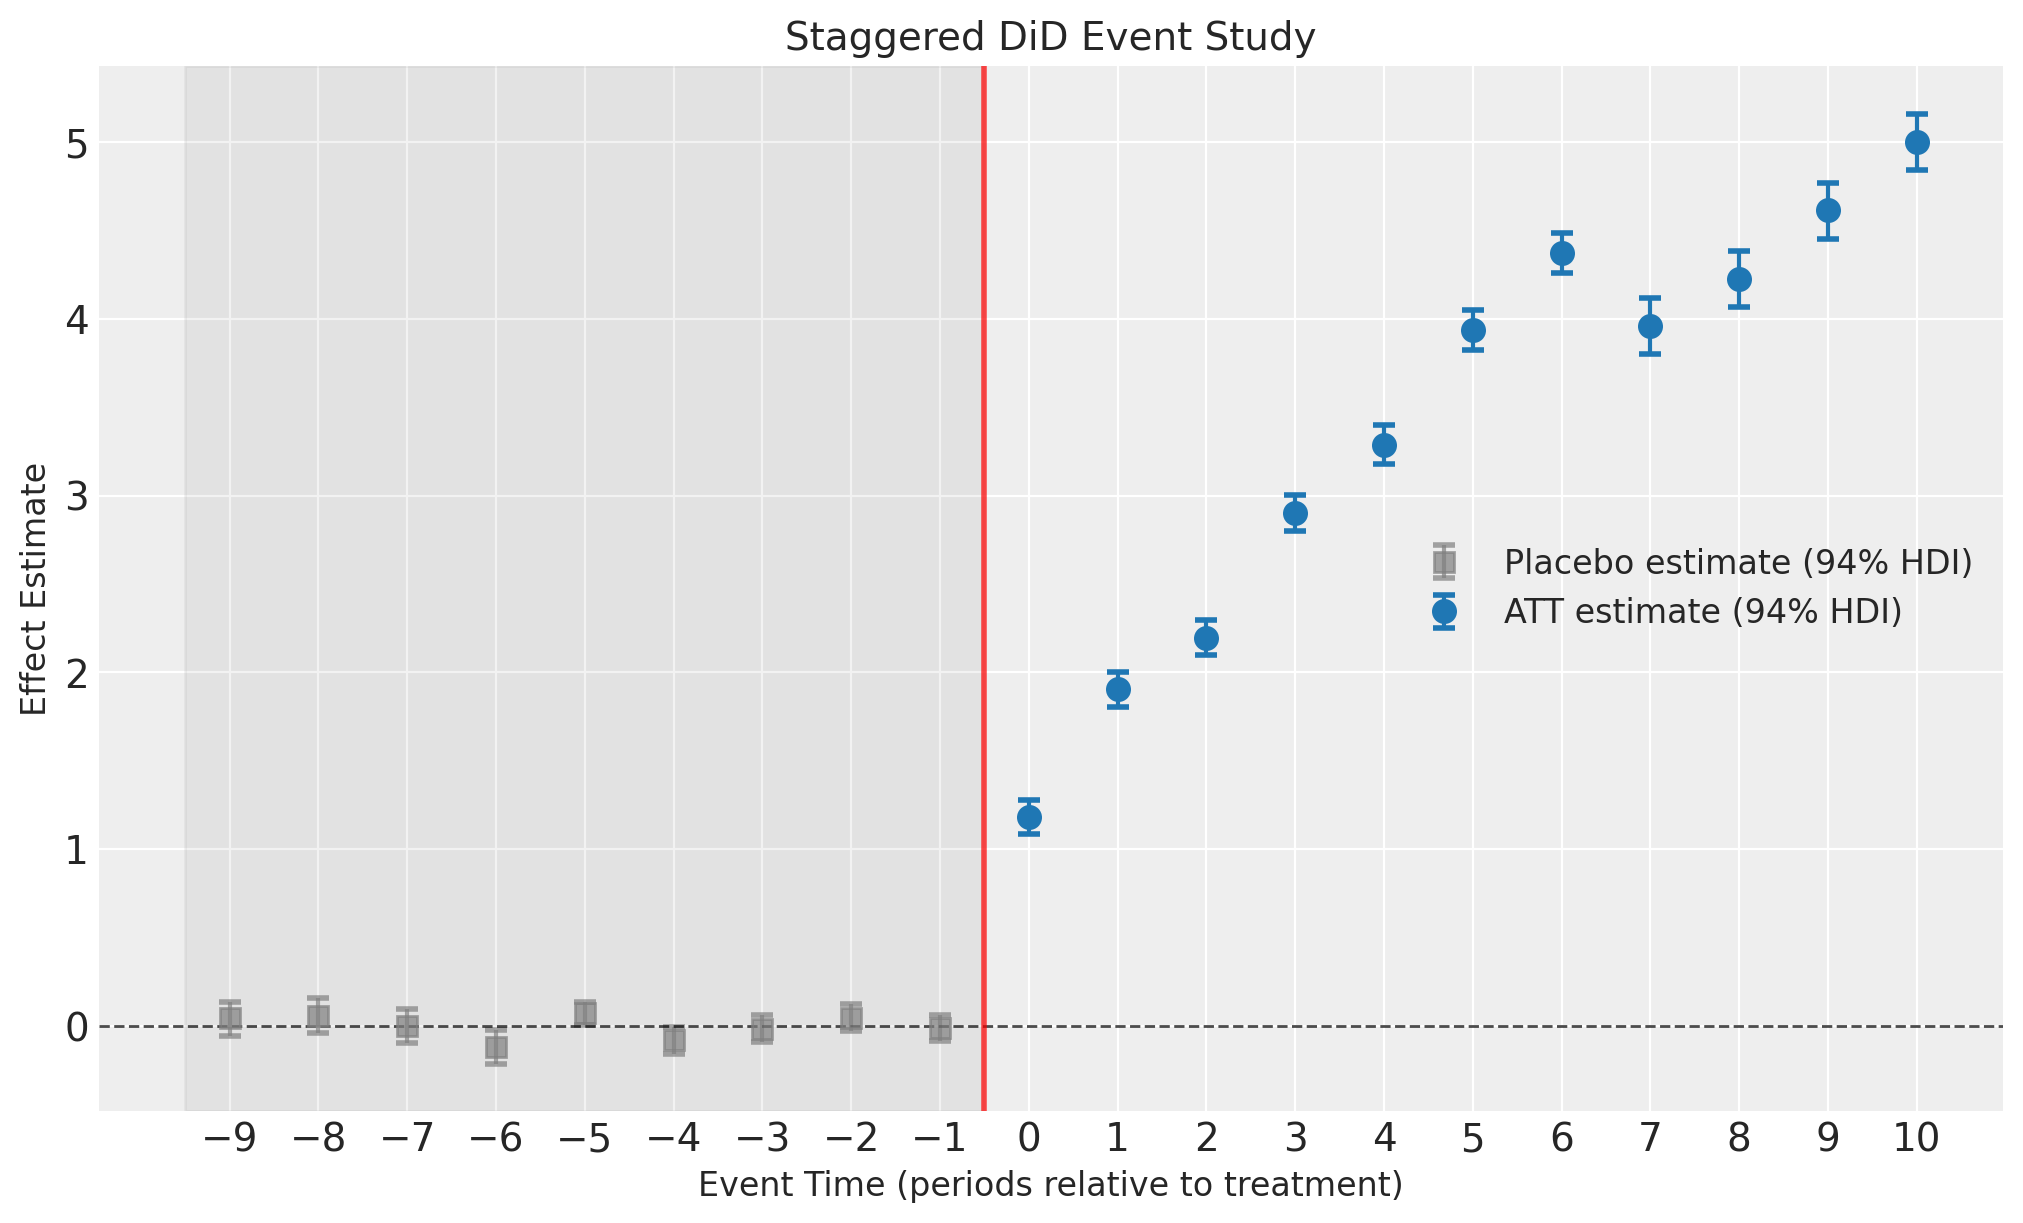

In [9]:
fig, ax = result_imputation.plot()
ax[0].set_title("Imputation estimator: event study")
plt.show()

The event-study curve rises roughly linearly, which is the shape we built in. What it does *not* show is which cohort contributed what: event time 3 pools the $G=5$ cohort's effect with the $G=9$ cohort's much larger one, and reports the average. That pooling is fine if you only want the aggregate. It is a loss of information if cohort heterogeneity is the thing you care about.

## 4. ETWFE with Mundlak conditioning

Now the same data through `estimator="etwfe"`. The call is identical apart from two keywords.

`conditioning="mundlak"` refers to the {cite:t}`mundlak1978pooling` device: instead of giving every unit a free intercept, the unit intercepts are **partially pooled** around a common mean, and the unit- and time-level means of the treatment indicator are entered as regressors. This is what makes the specification correlated-random-effects rather than fixed-effects, and it is the reason the model scales to panels with many more units than this one.

In [10]:
result_etwfe = cp.StaggeredDifferenceInDifferences(
    df,
    estimator="etwfe",
    conditioning="mundlak",
    model=cp.pymc_models.ETWFERegression(sample_kwargs=sample_kwargs),
    **shared,
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu_a, sd_a, a_z, sd_bt, beta_t, g_u, g_t, tau_bar, sd_dev, dev, y_hat_sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 88 seconds.


Sampling: [a_z, beta_t, dev, g_t, g_u, mu_a, sd_a, sd_bt, sd_dev, tau_bar, y_hat, y_hat_sigma]


Sampling: [y_hat]


### The in-model ATT

`att_` is the headline estimate. On the PyMC path it is an `xarray.DataArray` of posterior draws — the draws of the `att` deterministic defined inside the model — so it can be summarised, plotted or propagated like any other posterior quantity.

In [11]:
att_draws = result_etwfe.att_
att_hdi = az.hdi(att_draws, hdi_prob=0.94)["att"].values

print(f"Posterior mean ATT: {float(att_draws.mean()):.4f}")
print(f"94% HDI:            [{att_hdi[0]:.4f}, {att_hdi[1]:.4f}]")
print(f"True ATT:           {TRUE_ATT:.4f}")

Posterior mean ATT: 3.1777
94% HDI:            [3.0953, 3.2611]
True ATT:           3.2022


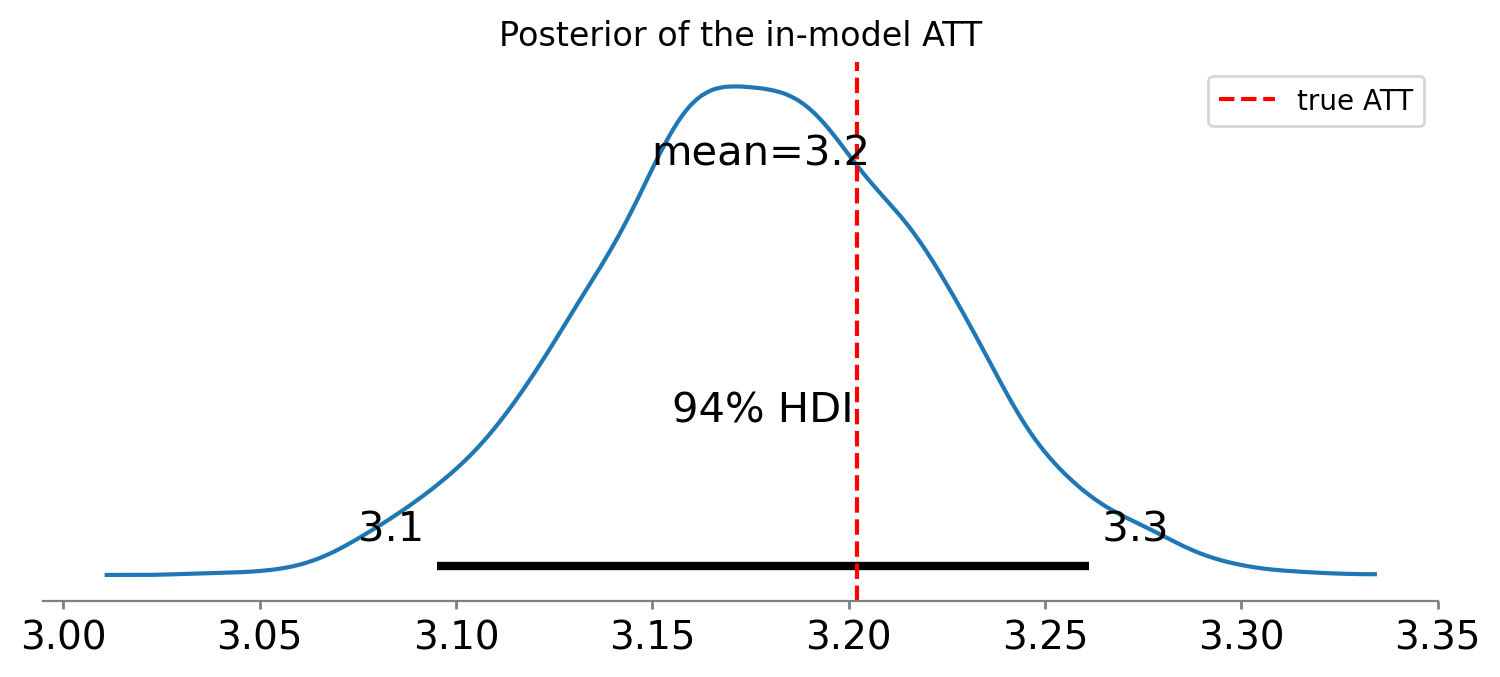

In [12]:
fig, ax = plt.subplots(figsize=(9, 3.5))
az.plot_posterior(att_draws, hdi_prob=0.94, ax=ax)
ax.axvline(TRUE_ATT, color="red", linestyle="--", label="true ATT")
ax.set_title("Posterior of the in-model ATT")
ax.legend()
plt.show()

:::{important}
This is the substantive difference from the imputation path. There, the treatment effect is a *post-hoc residual*: fit a model, predict, subtract, and assemble the uncertainty by differencing posterior-predictive draws outside the model. Here the aggregation

$$\text{att} = \sum_{g,k} w_{gk}\, \tau_{gk}$$

is a `pm.Deterministic` node in the model graph. Its posterior is produced by the sampler along with everything else, it respects the full joint dependence between the $\tau_{gk}$, and it is available for any downstream Bayesian operation without further reconstruction.
:::

Read the interval above with the usual care: the posterior of `att` should be centred near the true value and the 94% HDI should contain it. What you are looking for is a tight interval sitting on the truth, not the $0.38$-wide miss that the naive regression produced.

### The effect surface

`tau_surface_` is the object the aggregation is built from: one row per (cohort, event-time) cell that was actually estimated, in long form.

In [13]:
result_etwfe.tau_surface_.head(10)

,cohort,event_time,att,att_lower,att_upper,n_obs
0,5.0,0,0.761646,0.570248,0.960491,12
1,5.0,1,1.414566,1.212100,1.614051,12
2,5.0,2,1.691857,1.495434,1.886371,12
3,5.0,3,2.199854,1.994712,2.402916,12
4,5.0,4,2.408429,2.185181,2.620595,12
5,5.0,5,3.105823,2.889135,3.324369,12
6,5.0,6,3.291042,3.069845,3.510348,12
7,5.0,7,3.944064,3.723898,4.161585,12
8,5.0,8,4.217564,3.993608,4.440967,12
9,5.0,9,4.600174,4.377862,4.826538,12


In [14]:
att_weights = result_etwfe.att_weights_
print("Average-over-the-treated weights (rows = cohort, columns = event time):")
print(att_weights.round(4).to_string())
print()
print(f"Weights sum to {att_weights.to_numpy().sum():.6f}")
print(f"Estimated event times: {result_etwfe.event_time_grid_}")

Average-over-the-treated weights (rows = cohort, columns = event time):
event_time      0       1       2       3       4       5       6       7       8       9       10
cohort                                                                                            
5.0         0.0556  0.0556  0.0556  0.0556  0.0556  0.0556  0.0556  0.0556  0.0556  0.0556  0.0556
9.0         0.0556  0.0556  0.0556  0.0556  0.0556  0.0556  0.0556  0.0000  0.0000  0.0000  0.0000

Weights sum to 1.000000
Estimated event times: [ 0  1  2  3  4  5  6  7  8  9 10]


### The effect surface, plotted

`plot_tau_surface()` gives one panel per adoption cohort — the posterior mean $\tau_{gk}$ profile with an HDI band. This is the figure that the whole parametrisation exists to make possible: the aggregated event study of section 3 cannot show it, because it has already averaged the cohorts together.

The two panels should not look alike. Both profiles climb with event time, but the $G=9$ panel should climb noticeably more steeply, which is the `cohort_effect_scale={5: 1.0, 9: 1.6}` we put in.

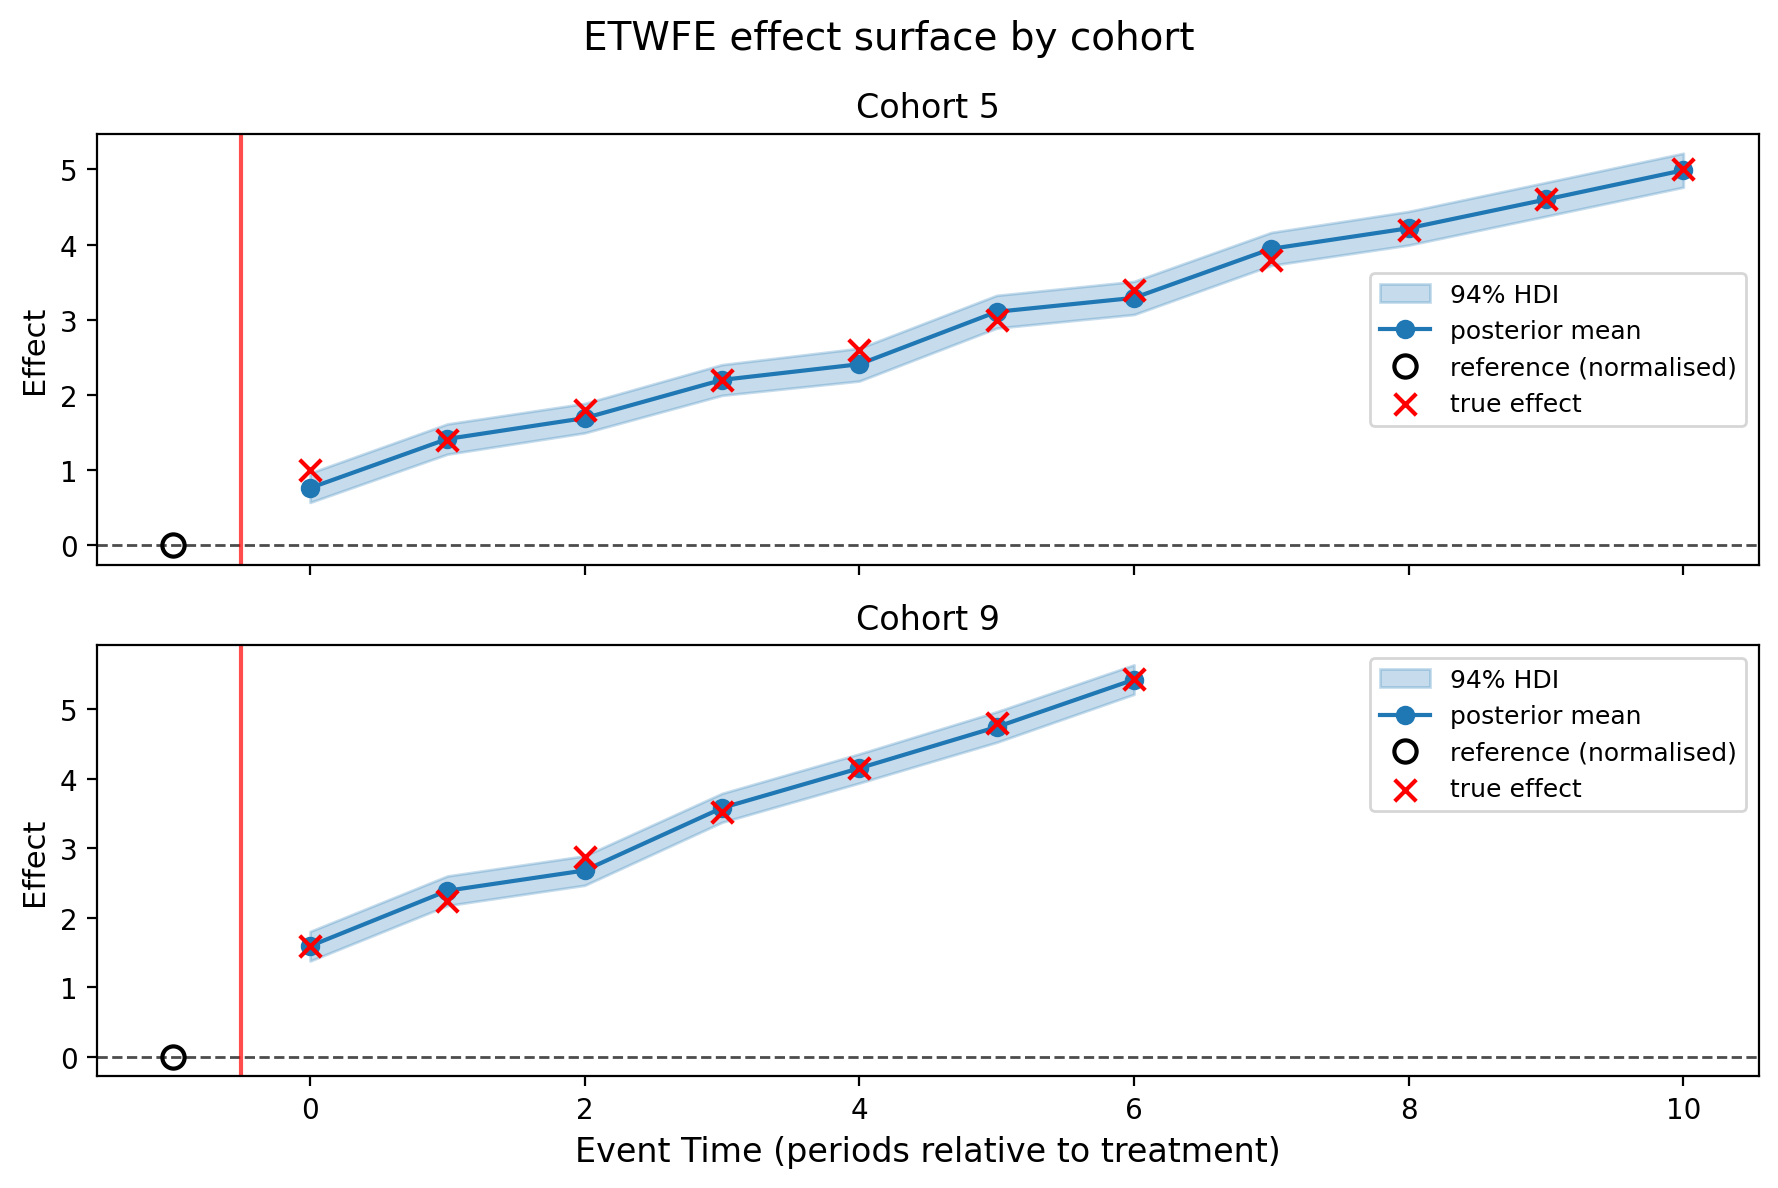

In [15]:
fig, axes = result_etwfe.plot_tau_surface(hdi_prob=0.94)

# Overlay the true cell effects; possible only because we simulated the data.
for ax, cohort in zip(axes, [5.0, 9.0]):
    rows = result_etwfe.tau_surface_.query("cohort == @cohort")
    scale = {5.0: 1.0, 9.0: 1.6}[cohort]
    truth = [(1 + 0.4 * k) * scale for k in rows["event_time"]]
    ax.scatter(
        rows["event_time"],
        truth,
        color="red",
        marker="x",
        s=60,
        zorder=5,
        label="true effect",
    )
    ax.legend(fontsize=9)

plt.show()

### Summary and prose

In [16]:
result_etwfe.summary(round_to=3)

======================Staggered Difference in Differences=======================
Formula: y ~ 1 + C(unit) + C(time)
Estimator: ETWFE (conditioning=mundlak)
Overall ATT: 3.178
Number of units: 40
Number of time periods: 16
Treatment cohorts: [np.float64(5.0), np.float64(9.0)]
Never-treated units: 16

Event-time estimates:
 event_time type      att  att_lower  att_upper  n_obs  identified
          0  ATT 1.177843   1.032251   1.323035     24        True
          1  ATT 1.902359   1.754726   2.050663     24        True
          2  ATT 2.186949   2.042904   2.332954     24        True
          3  ATT 2.890810   2.745478   3.031760     24        True
          4  ATT 3.280766   3.123452   3.431271     24        True
          5  ATT 3.925909   3.767979   4.086298     24        True
          6  ATT 4.359544   4.206104   4.513721     24        True
          7  ATT 3.944064   3.723898   4.161585     12        True
          8  ATT 4.217564   3.993608   4.440967     12        True
       

In [17]:
print(result_etwfe.effect_summary().text)

Average effect on the treated (in-model, treated-cell weighted): 3.18 (94% HDI [3.10, 3.26]). Staggered DiD analysis: The average post-treatment effect over treated observations was 3.18 (average 94% HDI [3.01, 3.34]). Analysis includes 2 treatment cohort(s).


The prose summary leads with the in-model, treated-cell-weighted ATT and its interval, then falls back to the event-time description that the imputation path also produces. The `att_event_time_` and `att_group_time_` tables have exactly the same schema as on the imputation path, so any downstream code that reads them keeps working.

## 5. Dummy conditioning

`conditioning="dummy"` is the other variant: a free `Normal` intercept per unit and zero-sum time effects, with no Mundlak means. It is the more literal reading of "two-way fixed effects" and is useful as a cross-check, because it makes a genuinely different set of modelling choices about the nuisance parameters while targeting the same $\tau$ surface.

In [18]:
result_dummy = cp.StaggeredDifferenceInDifferences(
    df,
    estimator="etwfe",
    conditioning="dummy",
    model=cp.pymc_models.ETWFERegression(sample_kwargs=sample_kwargs),
    **shared,
)

comparison = pd.DataFrame(
    {
        "conditioning": ["mundlak", "dummy"],
        "att_mean": [
            float(result_etwfe.att_.mean()),
            float(result_dummy.att_.mean()),
        ],
        "att_sd": [
            float(result_etwfe.att_.std()),
            float(result_dummy.att_.std()),
        ],
    }
)
comparison["true_att"] = TRUE_ATT
comparison

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha, beta_t, tau_bar, sd_dev, dev, y_hat_sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 37 seconds.


Sampling: [alpha, beta_t, dev, sd_dev, tau_bar, y_hat, y_hat_sigma]


Sampling: [y_hat]


,conditioning,att_mean,att_sd,true_att
0,mundlak,3.177743,0.043845,3.202222
1,dummy,3.177828,0.043466,3.202222


The two rows should agree closely: the conditioning scheme is a statement about the nuisance parameters $\alpha_i$ and $\lambda_t$, not about the estimand, and on a panel this size and this clean there is little for the choice to bite on.

### Why prefer Mundlak

- **It scales.** `"dummy"` adds one free parameter per unit. At 40 units that is unremarkable; at 40,000 it is a wall of weakly identified intercepts, and the sampler will tell you about it. Mundlak replaces them with a hierarchical mean and scale — the intercepts are still there, but partially pooled, so each one borrows strength from the rest.
- **It can absorb time-invariant covariates.** Free unit dummies are perfectly collinear with anything constant within unit, so a fixed-effects specification simply cannot estimate the coefficient on, say, a unit's region or its baseline size. Under partial pooling those covariates are estimable.
- **It is the honest version of the random-effects/fixed-effects compromise.** Entering the unit and time means of the treatment indicator is what buys back the consistency that a naive random-effects model would lose to correlation between the unit effect and treatment timing.

:::{warning}
Under `conditioning="mundlak"` the Mundlak *time* coefficient `g_t` **must not be interpreted**. The time mean of the treatment indicator is a function of the calendar period alone, so it lies exactly in the span of the time effects $\lambda_t$; `g_t` is identified only by its prior. This is a property of the Mundlak device, not a defect of the implementation, and it does not affect the ATT — $\tau$ is identified off within-cell variation, which is orthogonal to any function of $t$ alone.
:::

Note also that `conditioning="mundlak"` is **rejected** for scikit-learn models. With free unit dummies the Mundlak unit mean is exactly collinear with them; a pseudo-inverse would silently drop it and the result would be numerically identical to `"dummy"`. Genuine Mundlak conditioning needs partial pooling, which is what the PyMC path provides.

## 6. Lead terms as a pre-trend check

By default ETWFE estimates post-treatment cells only. Setting `n_leads=4` adds columns for event times $k = -4, -3, -2$ — pre-treatment periods for units that are *about to* adopt.

Two points about the indexing:

- **The reference event time is omitted, not zeroed.** With `reference_event_time=-1` (the default), no column exists for $k=-1$; every other effect is read relative to it. Keeping the column with a zero constraint would create a free parameter with no likelihood contribution — a guaranteed convergence complaint and a misleading posterior. The plots mark the omitted reference explicitly.
- **Cells with $k < -n_{\text{leads}}$ remain clean controls.** They are not-yet-treated observations, and that is exactly the identifying variation. Leads are a free diagnostic; they do not change the estimand, because the ATT weights are built from treated cells only and are therefore exactly zero on the lead columns.

We run this on the scikit-learn path so the numbers below are deterministic OLS output.

In [19]:
result_leads = cp.StaggeredDifferenceInDifferences(
    df,
    estimator="etwfe",
    n_leads=4,
    model=LinearRegression(),
    **shared,
)

print(f"Estimated event times: {result_leads.event_time_grid_}")
print("(note that -1, the reference, is absent by construction)")
print()
result_leads.att_event_time_

Estimated event times: [-4 -3 -2  0  1  2  3  4  5  6  7  8  9 10]
(note that -1, the reference, is absent by construction)



/Users/nathanielforde/Documents/Github/CausalPy/causalpy/experiments/base.py:198: UserWarning: LinearRegression had fit_intercept=True, but CausalPy requires fit_intercept=False because the intercept is already included in the design matrix by patsy. A cloned copy of the model with fit_intercept=False will be used; the original instance is unchanged.
  adapter = make_model_adapter(


,event_time,att,att_std,n_obs,identified
0,-4,-0.127161,0.097487,24,True
1,-3,-0.031490,0.080930,24,True
2,-2,0.049698,0.085707,24,True
3,0,1.150598,0.101955,24,True
4,1,1.880994,0.095266,24,True
5,2,2.151348,0.072753,24,True
6,3,2.900365,0.105611,24,True
7,4,3.274376,0.089756,24,True
8,5,3.925373,0.110374,24,True
9,6,4.359791,0.067117,24,True


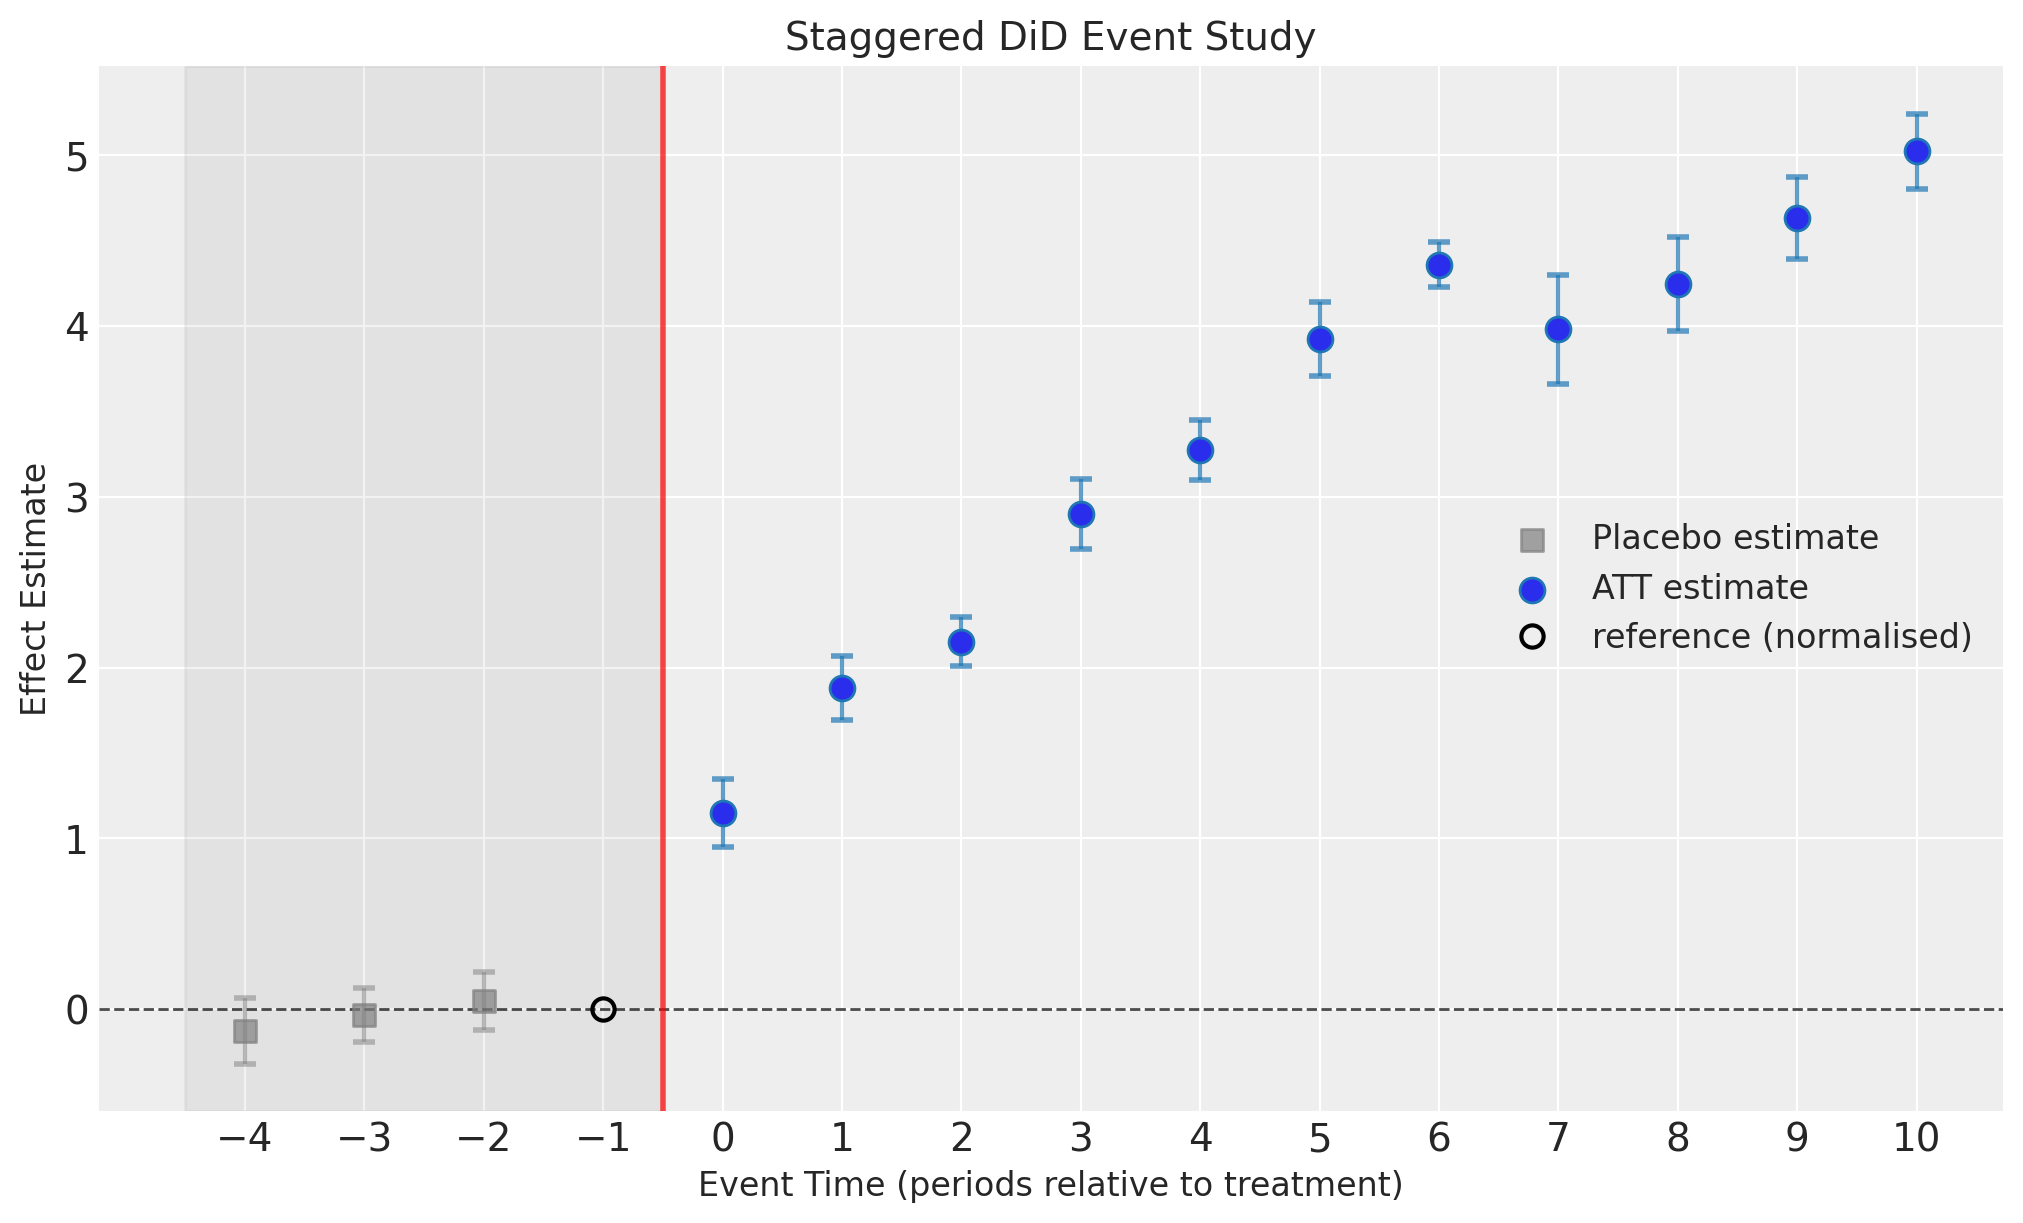

In [20]:
fig, ax = result_leads.plot()
ax[0].set_title("ETWFE with 4 leads: event study")
plt.show()

The three lead estimates sit close to zero relative to the post-treatment effects, which is what a credible {term}`Parallel trends assumption` looks like in this design — and it should be, since we generated the data with no pre-trend at all.

`PreTreatmentPlaceboCheck` formalises this. Its criterion is relative: it passes when the *mean* pre-treatment ATT is within `threshold` times the *largest absolute* pre-treatment ATT of zero. That is a scale-free test of whether the leads scatter symmetrically around zero rather than drifting in one direction, which is the failure mode that matters. It is deliberately not a test of whether each individual lead is small.

In [21]:
placebo = cp.Pipeline(
    data=df,
    steps=[
        cp.EstimateEffect(
            method=cp.StaggeredDifferenceInDifferences,
            estimator="etwfe",
            n_leads=4,
            model=LinearRegression(),
            **shared,
        ),
        cp.SensitivityAnalysis(
            checks=[cp.checks.PreTreatmentPlaceboCheck(threshold=0.5)]
        ),
    ],
).run()

for check_result in placebo.sensitivity_results:
    print(check_result.text)

/Users/nathanielforde/Documents/Github/CausalPy/causalpy/experiments/base.py:198: UserWarning: LinearRegression had fit_intercept=True, but CausalPy requires fit_intercept=False because the intercept is already included in the design matrix by patsy. A cloned copy of the model with fit_intercept=False will be used; the original instance is unchanged.
  adapter = make_model_adapter(


Pre-treatment placebo check passed: mean pre-treatment ATT = -0.0363, consistent with parallel trends.


:::{important}
Passing a pre-treatment placebo check is a necessary but not sufficient condition. It says the groups were not visibly diverging *before* treatment; it cannot tell you they would have continued to move together *after* {cite:p}`goodmanbacon2021difference`.
:::

## 7. Covariates

Additional covariates are supplied through the explicit `covariates=` argument, not through the formula's right-hand side. The ETWFE path builds its own saturated design and uses only the **left-hand side** of `formula`; a `UserWarning` names any right-hand-side term beyond `1`, `0`, `C(unit)` and `C(time)`. This is what lets you flip `estimator=` on an otherwise unchanged call without producing a rank-deficient design.

Regenerate the same panel with two observed covariates folded into the outcome, then fit with and without them.

In [22]:
df_cov = generate_staggered_did_data(
    n_covariates=2, covariate_coefs=[1.5, -0.8], **sim_kwargs
)

fit_kwargs = dict(estimator="etwfe", model=LinearRegression(), **shared)

result_nocov = cp.StaggeredDifferenceInDifferences(df_cov, **fit_kwargs)
result_cov = cp.StaggeredDifferenceInDifferences(
    df_cov, covariates=["x1", "x2"], **fit_kwargs
)

pd.DataFrame(
    {
        "specification": ["covariates omitted", "covariates included"],
        "att": [result_nocov.att_, result_cov.att_],
        "att_se": [result_nocov.att_se_, result_cov.att_se_],
        "true_att": TRUE_ATT,
    }
)

/Users/nathanielforde/Documents/Github/CausalPy/causalpy/experiments/base.py:198: UserWarning: LinearRegression had fit_intercept=True, but CausalPy requires fit_intercept=False because the intercept is already included in the design matrix by patsy. A cloned copy of the model with fit_intercept=False will be used; the original instance is unchanged.
  adapter = make_model_adapter(
/Users/nathanielforde/Documents/Github/CausalPy/causalpy/experiments/base.py:198: UserWarning: LinearRegression had fit_intercept=True, but CausalPy requires fit_intercept=False because the intercept is already included in the design matrix by patsy. A cloned copy of the model with fit_intercept=False will be used; the original instance is unchanged.
  adapter = make_model_adapter(


,specification,att,att_se,true_att
0,covariates omitted,3.123488,0.281754,3.202222
1,covariates included,3.187592,0.048971,3.202222


Including the covariates shrinks the standard error from $0.282$ to $0.049$, a factor of roughly 5.7, and moves the point estimate from $3.12$ to $3.19$ against a truth of $3.20$.

:::{important}
**Be clear about what happened there.** The covariates in this generator are drawn iid from $N(0,1)$, independently of unit, of time, and of treatment timing. They are therefore **not confounders**. Omitting them cannot bias the ETWFE estimate — it only leaves their contribution in the error term, inflating the residual variance and hence every standard error. What you are seeing is **variance reduction, not bias reduction**, and the small movement in the point estimate is sampling noise, not the correction of a bias.

In a real application covariates may well be confounders, and then including them matters for identification as well as precision. This simulation does not demonstrate that, and it would be a misreading to claim it does.
:::

:::{note}
**Covariates enter additively in this implementation.** Wooldridge's full ETWFE specification interacts *centred* covariates with each $(g,k)$ cell, which allows the treatment effect itself to vary with covariate values. That is not implemented in v1; the covariates here shift the untreated potential outcome only. It is noted as future work.
:::

## 8. The scikit-learn path and cluster-robust standard errors

Passing any scikit-learn regressor gives an OLS fit of the saturated design. `conditioning` resolves to `"dummy"` automatically, and inference comes from a sandwich estimator rather than a posterior.

`se_type="cluster"` (the default) clusters by unit, which is the right default for panel data: observations on the same unit share an unmodelled unit-level shock, so treating them as independent understates uncertainty. `se_type="classical"` is available for comparison and should generally be the smaller of the two.

The ATT standard error here is a proper linear combination, $\text{se}(\hat{a}) = \sqrt{w' V w}$ with $w$ the ATT weight vector — not a within-group standard deviation of point estimates.

In [23]:
result_cluster = cp.StaggeredDifferenceInDifferences(
    df, estimator="etwfe", se_type="cluster", model=LinearRegression(), **shared
)
result_classical = cp.StaggeredDifferenceInDifferences(
    df, estimator="etwfe", se_type="classical", model=LinearRegression(), **shared
)

print(f"Generated saturated formula:\n  {result_cluster.etwfe_formula_}")
print()
print(f"ATT (point estimate):    {result_cluster.att_:.4f}")
print(f"  cluster-robust SE:     {result_cluster.att_se_:.4f}")
print(f"  classical SE:          {result_classical.att_se_:.4f}")
print(f"True ATT:                {TRUE_ATT:.4f}")

Generated saturated formula:
  y ~ 1 + C(unit) + C(time) + C(_gk_cell, Treatment(reference='__none__'))

ATT (point estimate):    3.1876
  cluster-robust SE:     0.0492
  classical SE:          0.0437
True ATT:                3.2022


/Users/nathanielforde/Documents/Github/CausalPy/causalpy/experiments/base.py:198: UserWarning: LinearRegression had fit_intercept=True, but CausalPy requires fit_intercept=False because the intercept is already included in the design matrix by patsy. A cloned copy of the model with fit_intercept=False will be used; the original instance is unchanged.
  adapter = make_model_adapter(
/Users/nathanielforde/Documents/Github/CausalPy/causalpy/experiments/base.py:198: UserWarning: LinearRegression had fit_intercept=True, but CausalPy requires fit_intercept=False because the intercept is already included in the design matrix by patsy. A cloned copy of the model with fit_intercept=False will be used; the original instance is unchanged.
  adapter = make_model_adapter(


### Everything side by side

The Bayesian rows are posterior means, so they will differ slightly from run to run; the OLS rows are deterministic.

In [24]:
imputation_data = result_imputation.data_
treated_rows = imputation_data[imputation_data["treated"] == 1]

summary_rows = [
    ("naive single-delta TWFE", delta_twfe),
    ("imputation, treated-cell mean (PyMC)", treated_rows["tau_hat"].mean()),
    (
        "imputation, mean of event-time ATTs (PyMC)",
        result_imputation.att_event_time_.query("event_time >= 0")["att"].mean(),
    ),
    ("ETWFE mundlak (PyMC)", float(result_etwfe.att_.mean())),
    ("ETWFE dummy (PyMC)", float(result_dummy.att_.mean())),
    ("ETWFE (OLS, cluster SE)", result_cluster.att_),
]

comparison_table = pd.DataFrame(summary_rows, columns=["estimator", "estimate"])
comparison_table["true_att"] = TRUE_ATT
comparison_table["abs_error"] = (comparison_table["estimate"] - TRUE_ATT).abs()
comparison_table.round(4)

,estimator,estimate,true_att,abs_error
0,naive single-delta TWFE,2.8219,3.2022,0.3803
1,"imputation, treated-cell mean (PyMC)",3.1871,3.2022,0.0151
2,"imputation, mean of event-time ATTs (PyMC)",3.4169,3.2022,0.2147
3,ETWFE mundlak (PyMC),3.1777,3.2022,0.0245
4,ETWFE dummy (PyMC),3.1778,3.2022,0.0244
5,"ETWFE (OLS, cluster SE)",3.1876,3.2022,0.0146


:::{important}
**The two imputation rows are the same fit, summarised two different ways**, and the gap between them is the point of the table. The unweighted mean of post-treatment event-time ATTs gives event time 10 — reached by only one cohort, so 12 observations — the same say as event time 3, which has 24. Because effects grow with event time, the thin late cells are also the large ones, and the unweighted mean is pulled upward. Averaging over treated *cells* instead — which is what `att_` does by construction — targets the estimand directly.

Row 2 is computed by hand here to expose the contrast. You do not have to guard against it yourself: `effect_summary()` weights each event time by its treated-observation count on **both** estimator paths, so the number it reports is the treated-cell average rather than the row mean. The trap is only live if you average `att_event_time_["att"]` yourself.

This is not a criticism of the imputation estimator; it is a criticism of summarising it by eye. ETWFE simply makes the choice unavoidable: the weights $w_{gk}$ are written down in `att_weights_`, entered into the model, and the weighted sum $\sum_{g,k} w_{gk}\tau_{gk}$ *is* the number the model reports.
:::

## Key takeaways

1. **A single treatment coefficient is the problem.** With staggered adoption plus dynamic or cohort-heterogeneous effects, the scalar $\delta$ in a TWFE regression is a weighted average of $2\times2$ comparisons, some of which use already-treated — and therefore still-trending — units as controls. Here that cost 12% of the true effect.

2. **ETWFE fixes it by refusing to average early.** One parameter per (cohort, event-time) cell, aggregated afterwards with explicit, inspectable weights (`att_weights_`).

3. **The ATT is a model parameter, not a post-hoc residual.** On the PyMC path `att_` is the posterior of a `pm.Deterministic` defined inside the model. That is the substantive difference from the imputation estimator, which assembles its uncertainty by differencing posterior-predictive draws after the fact.

4. **`tau_surface_` and `plot_tau_surface()` are where cohort heterogeneity lives.** The aggregated event study has already averaged it away.

5. **Conditioning is a choice about nuisance parameters.** `"mundlak"` partially pools the unit intercepts and scales past a few dozen units; `"dummy"` gives each unit a free intercept and is the literal fixed-effects reading. They should agree on the estimand.

6. **`n_leads` buys a pre-trend diagnostic for free.** The lead columns carry zero ATT weight, so they change nothing about the estimand — and the reference event time is omitted from the design rather than constrained to zero.

7. **Both estimators live behind one entry point.** `estimator="imputation"` and `estimator="etwfe"` are two keywords on the same class, so comparing them costs one line.

## Further reading

{cite:t}`callaway2021difference` develop a closely related group-time ATT estimator with its own aggregation schemes; {cite:t}`goodmanbacon2021difference` is the decomposition that diagnoses the naive estimator; {cite:t}`wooldridge2021twoway` is the ETWFE source, and {cite:t}`mundlak1978pooling` the correlated-random-effects device it rests on.

## References

:::{bibliography}
:filter: docname in docnames
:::